In [963]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# pip install numpy pandas 
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# pip install kagglehub
import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# pip install matplotlib
import matplotlib.pyplot as plt


In [964]:
train_data = pd.read_csv("train.csv")
train_data.head()



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [965]:
train_data.shape # (Anzahl_Zeilen: 891, Anzahl_Spalten: 12)

(891, 12)

In [966]:
# Check column types
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [967]:
# Check missing values
train_data.isna().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

In [968]:
# Statistical summary of the dataset
train_data.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


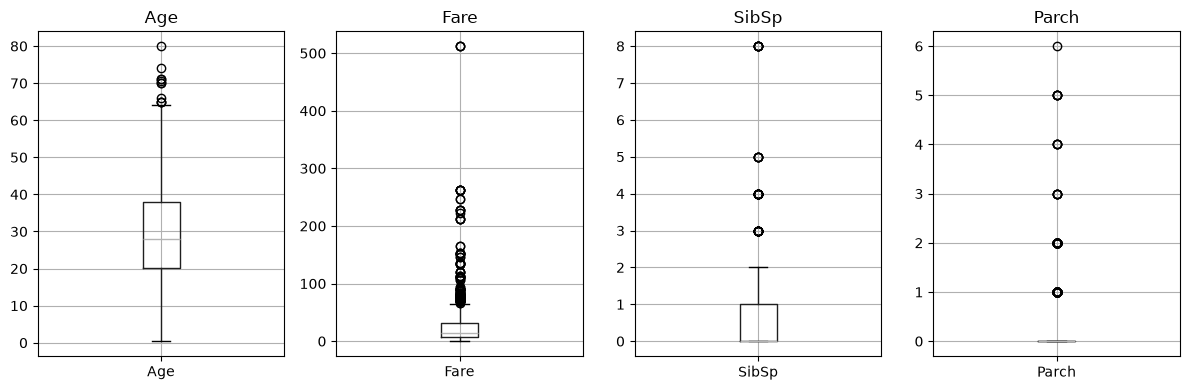

In [969]:
columns = ["Age", "Fare", "SibSp", "Parch"]

fig, axes = plt.subplots(1, 4, figsize=(12, 4))

for ax, column in zip(axes, columns):
    train_data.boxplot(column=column, ax=ax)
    ax.set_title(column)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

- **Age:** Das mittlere Alter beträgt etwa **29,7 Jahre**, der Median **28 Jahre**; die mittleren 50 % liegen zwischen **20,1 und 38 Jahren**, während einzelne hohe Alterswerte im Boxplot als Ausreißer erscheinen.
- **Fare:** Der durchschnittliche Fahrpreis beträgt **32,20**, der Median jedoch nur **14,45**; die mittleren 50 % liegen zwischen **7,91 und 31,00**, und viele hohe Preise bis **512,33** machen die Verteilung stark rechtsschief.
- **SibSp:** Die meisten Passagiere hatten keine Geschwister oder Ehepartner an Bord; der Median ist **0**, die mittleren 50 % liegen zwischen **0 und 1**, und Werte ab **3** erscheinen als Ausreißer.
- **Parch:** Mindestens 75 % der Passagiere hatten keine Eltern oder Kinder an Bord; deshalb liegen Median und beide Quartile bei **0**, die Box fällt zusammen und alle positiven Werte bis **6** erscheinen als Ausreißer.

## Gesamtüberlebensrate

In [970]:
# Survival balance
survival_balance = pd.DataFrame({
    "passengers": train_data["Survived"].value_counts(),
    "survival_rate": train_data["Survived"]
        .value_counts(normalize=True).mul(100).round(1)
}).rename(index={0: "Nicht überlebt", 1: "Überlebt"})

survival_balance
# 61.6% of passengers did not survive
# 38.4% of passengers survived

,passengers,survival_rate
Survived,,
Nicht überlebt,549,61.6
Überlebt,342,38.4


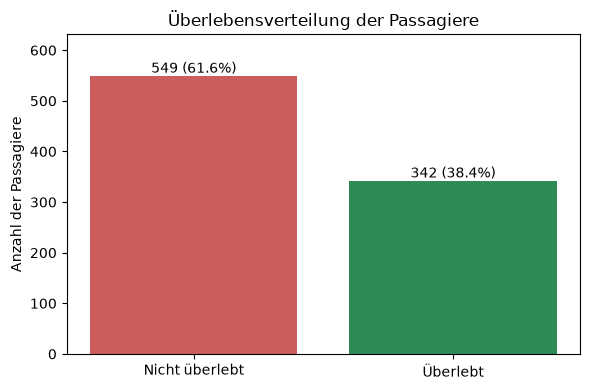

In [971]:
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    survival_balance.index,
    survival_balance["passengers"],
    color=["indianred", "seagreen"]
)

for bar, count, rate in zip(
    bars,
    survival_balance["passengers"],
    survival_balance["survival_rate"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count} ({rate:.1f}%)",
        ha="center",
        va="bottom"
    )

ax.set_title("Überlebensverteilung der Passagiere")
ax.set_ylabel("Anzahl der Passagiere")
ax.set_ylim(0, survival_balance["passengers"].max() * 1.15)

plt.tight_layout()
plt.show()

## Überlebensrate nach Geschlecht

In [972]:
# Survival rate by gender
sex_survival = (
    train_data.groupby("Sex")["Survived"]
    .agg(passengers="count", survival_rate="mean")
)

sex_survival["survival_rate"] = (
    sex_survival["survival_rate"] * 100
).round(1)

sex_survival
# 74.2% of females survived
# 18.9% of males survived

,passengers,survival_rate
Sex,,
female,314,74.2
male,577,18.9


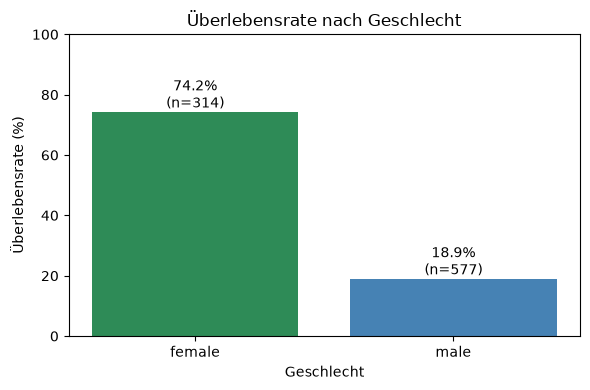

In [973]:
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    sex_survival.index,
    sex_survival["survival_rate"],
    color=["seagreen", "steelblue"]
)

for bar, count, rate in zip(
    bars,
    sex_survival["passengers"],
    sex_survival["survival_rate"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%\n(n={count})",
        ha="center",
        va="bottom"
    )

ax.set_title("Überlebensrate nach Geschlecht")
ax.set_xlabel("Geschlecht")
ax.set_ylabel("Überlebensrate (%)")
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

## Überlebensrate nach Klasse

In [974]:
# Survival rate by class
class_survival = (
    train_data.groupby("Pclass")["Survived"]
    .agg(passengers="count", survival_rate="mean")
)

class_survival["survival_rate"] = (
    class_survival["survival_rate"] * 100
).round(1)

class_survival

,passengers,survival_rate
Pclass,,
1,216,63.0
2,184,47.3
3,491,24.2


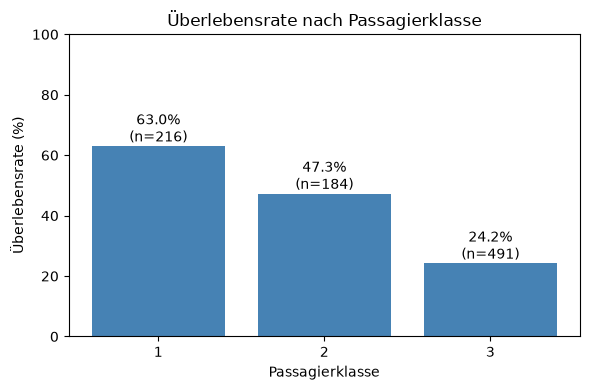

In [975]:
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    class_survival.index.astype(str),
    class_survival["survival_rate"],
    color="steelblue"
)

for bar, count, rate in zip(
    bars,
    class_survival["passengers"],
    class_survival["survival_rate"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%\n(n={count})",
        ha="center",
        va="bottom"
    )

ax.set_title("Überlebensrate nach Passagierklasse")
ax.set_xlabel("Passagierklasse")
ax.set_ylabel("Überlebensrate (%)")
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

## Überlebensrate nach Altersgruppen

In [976]:
# Survival rate by age group
train_data['AgeGroup'] = pd.cut(train_data['Age'], bins=[0, 12, 18, 35, 60, 80], labels=['Child', 'Teenager', 'Adult', 'Middle-aged', 'Senior'])
train_data["AgeGroup"] = train_data["AgeGroup"].cat.add_categories("Unknown").fillna("Unknown")

age_survival = (
    train_data.groupby("AgeGroup", observed=True)["Survived"]
    .agg(passengers="count", survival_rate="mean")
)

age_survival["survival_rate"] = (
    age_survival["survival_rate"] * 100
).round(1)

age_survival
# 58.0% of children survived <-- höchste Überlebensrate
# 42.9% of teenagers survived
# 38.3% of adults survived
# 40.0% of middle-aged survived
# 22.7% of seniors survived <-- niedrigste Überlebensrate
# 29.4% of unknown age survived

,passengers,survival_rate
AgeGroup,,
Child,69,58.0
Teenager,70,42.9
Adult,358,38.3
Middle-aged,195,40.0
Senior,22,22.7
Unknown,177,29.4


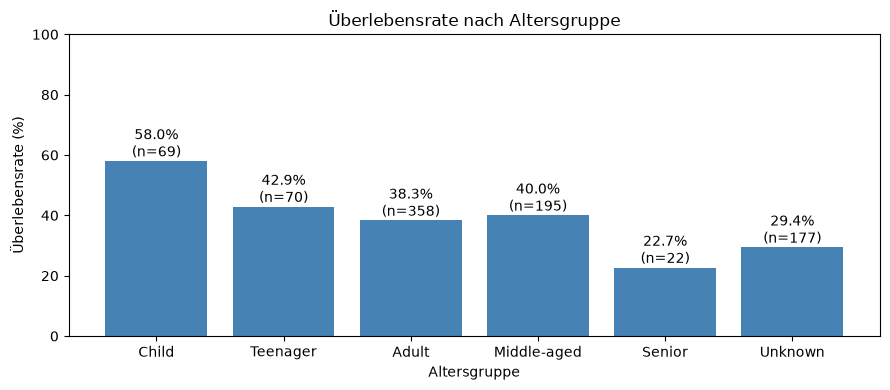

In [977]:
fig, ax = plt.subplots(figsize=(9, 4))

bars = ax.bar(
    age_survival.index.astype(str),
    age_survival["survival_rate"],
    color="steelblue"
)

for bar, count, rate in zip(
    bars,
    age_survival["passengers"],
    age_survival["survival_rate"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%\n(n={count})",
        ha="center",
        va="bottom"
    )

ax.set_title("Überlebensrate nach Altersgruppe")
ax.set_xlabel("Altersgruppe")
ax.set_ylabel("Überlebensrate (%)")
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

## Überlebensrate nach Title

In [978]:
# Survival rate by title
train_data["Title"] = train_data["Name"].str.extract(r",\s*([^.]*)\.", expand=False).str.strip()

title_survival = (
    train_data.groupby("Title")
    .agg(
        passengers=("Survived", "count"),
        survival_rate=("Survived", "mean")
    )
    .sort_values("passengers", ascending=False)
)

title_survival["survival_rate"] = (title_survival["survival_rate"] * 100).round(1)
title_survival # Mrs, Miss, Master, Mr and Others

,passengers,survival_rate
Title,,
Mr,517,15.7
Miss,182,69.8
Mrs,125,79.2
Master,40,57.5
Dr,7,42.9
Rev,6,0.0
Mlle,2,100.0
Major,2,50.0
Col,2,50.0


In [979]:
main_titles = ["Mrs", "Miss", "Master", "Mr"]
train_data["TitleGroup"] = train_data["Title"].where(train_data["Title"].isin(main_titles), "Rare Titles")

title_survival = train_data.groupby("TitleGroup").agg(
    passengers=("Survived", "count"),
    survival_rate=("Survived", "mean")
)

title_survival["survival_rate"] = title_survival["survival_rate"].mul(100).round(1)
title_survival = title_survival.sort_values(by="survival_rate", ascending=False)

title_survival
# 79,2% of Mrs survived <-- höchste Überlebensrate (verheiratete Frauen)
# 69.8% of Miss survived
# 57.5% of Master survived
# 44.4% of Rare Titles survived
# 15.7% of Mr survived <-- niedrigste Überlebensrate (Vgl.: 18.9% of males survived)

,passengers,survival_rate
TitleGroup,,
Mrs,125,79.2
Miss,182,69.8
Master,40,57.5
Rare Titles,27,44.4
Mr,517,15.7


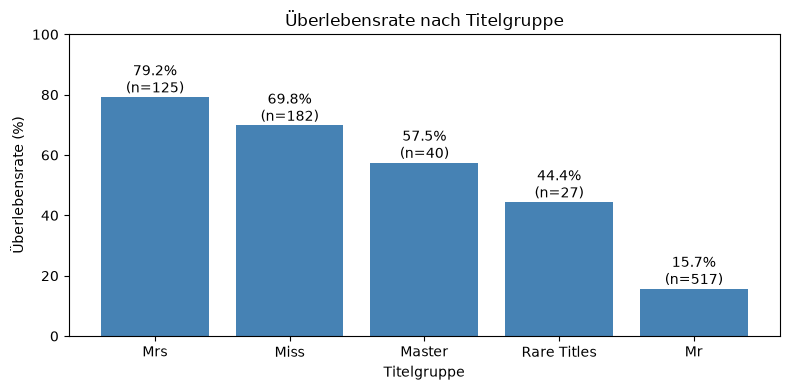

In [980]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(
    title_survival.index,
    title_survival["survival_rate"],
    color="steelblue"
)

for bar, count, rate in zip(
    bars,
    title_survival["passengers"],
    title_survival["survival_rate"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%\n(n={count})",
        ha="center",
        va="bottom"
    )

ax.set_title("Überlebensrate nach Titelgruppe")
ax.set_xlabel("Titelgruppe")
ax.set_ylabel("Überlebensrate (%)")
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

## Überlebensrate nach Ticketpreis

In [981]:
# Survival rate by fare
train_data["FareGroup"] = pd.cut(
    train_data["Fare"],
    bins=[-float("inf"), 40, 80, float("inf")],
    labels=["0-40", "40-80", ">80"]
)

fare_survival = (
    train_data.groupby("FareGroup", observed=True)["Survived"]
    .agg(passengers="count", survival_rate="mean")
)

fare_survival["survival_rate"] = (
    fare_survival["survival_rate"] * 100
).round(1)

fare_survival
# 77% of passengers with fare >80 survived <-- höchste Überlebensrate
# 54.9% of passengers with fare 40-80 survived
# 32% of passengers with fare 0-40 survived

,passengers,survival_rate
FareGroup,,
0-40,715,32.0
40-80,102,54.9
>80,74,77.0


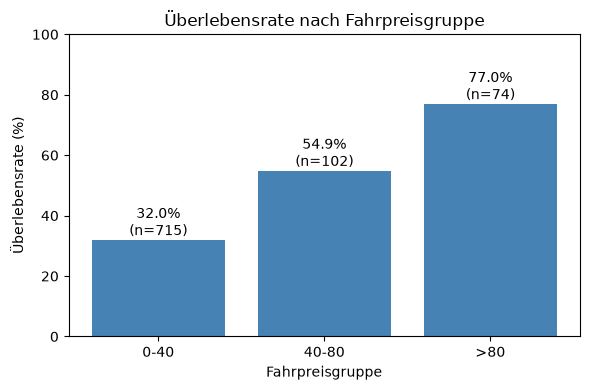

In [982]:
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    fare_survival.index.astype(str),
    fare_survival["survival_rate"],
    color="steelblue"
)

for bar, count, rate in zip(
    bars,
    fare_survival["passengers"],
    fare_survival["survival_rate"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%\n(n={count})",
        ha="center",
        va="bottom"
    )

ax.set_title("Überlebensrate nach Fahrpreisgruppe")
ax.set_xlabel("Fahrpreisgruppe")
ax.set_ylabel("Überlebensrate (%)")
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

## Überlebensrate nach Familiengröße

In [983]:
# Anzahl an Passagieren mit/ohne Eltern/Kindern an Bord
train_data["Parch"].value_counts().sort_index()
##   0: 678
##   1: 118
## > 1: 95

Parch
0    678
1    118
2     80
3      5
4      4
5      5
6      1
Name: count, dtype: int64

In [984]:
# Familiengröße inklusive der Person selbst
train_data["FamilySize"] = train_data["SibSp"] + train_data["Parch"] + 1

In [985]:
train_data["FamilySize"] = train_data["SibSp"] + train_data["Parch"] + 1

train_data["FamilySizeGroup"] = pd.cut(
    train_data["FamilySize"],
    bins=[0, 1, 2, 3, 4, 5, float("inf")],
    labels=["1", "2", "3", "4", "5", ">5"]
)

family_survival = (
    train_data.groupby("FamilySizeGroup", observed=True)["Survived"]
    .agg(passengers="count", survival_rate="mean")
)

family_survival["survival_rate"] = (
    family_survival["survival_rate"] * 100
).round(1)

family_survival
# 4: 72.4 % <-- höchste Überlebensrate (nur 29 Passagiere)
# > 5; 14.9% <-- niedrigste Überlebensrate (nur 47 Passagiere)

,passengers,survival_rate
FamilySizeGroup,,
1,537,30.4
2,161,55.3
3,102,57.8
4,29,72.4
5,15,20.0
>5,47,14.9


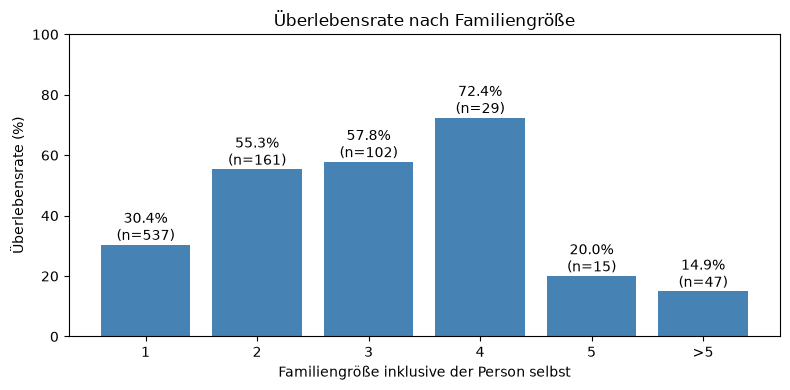

In [986]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(
    family_survival.index.astype(str),
    family_survival["survival_rate"],
    color="steelblue"
)

for bar, count, rate in zip(
    bars,
    family_survival["passengers"],
    family_survival["survival_rate"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%\n(n={count})",
        ha="center",
        va="bottom"
    )

ax.set_title("Überlebensrate nach Familiengröße")
ax.set_xlabel("Familiengröße inklusive der Person selbst")
ax.set_ylabel("Überlebensrate (%)")
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

## Erste Zsfg.

- Geschlecht, Titel, Fare zeigen Überlebensraten > 75 %
- Frauen ~74%
- verheiratete Frauen ~79%
- Rich folks (Fare>80) ~77%
- 1st Class ~63%
- Männer ~18%
- Mr ~15%
- große Familien (5 und >5) ~20% und ~15%



## Geschlecht und Klasse

In [987]:
sex_class_survival = train_data.groupby(["Sex", "Pclass"]).agg(
    passengers=("Survived", "count"),
    survival_rate=("Survived", "mean")
)

sex_class_survival["survival_rate"] = (
    sex_class_survival["survival_rate"].mul(100).round(1)
)

sex_class_survival

passengers  survival_rate
Sex    Pclass                           
female 1               94           96.8
       2               76           92.1
       3              144           50.0
male   1              122           36.9
       2              108           15.7
       3              347           13.5

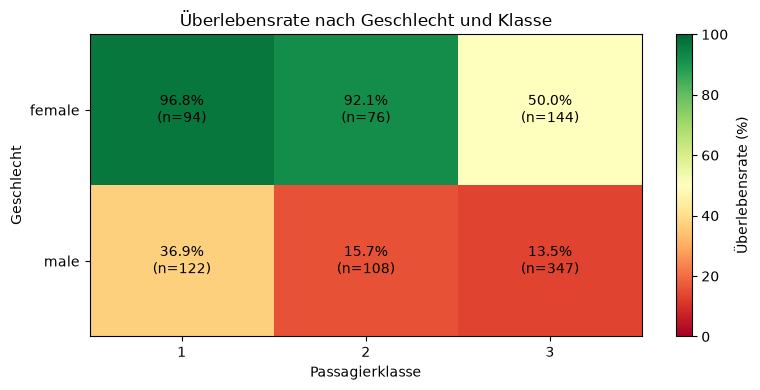

In [988]:
rates = sex_class_survival["survival_rate"].unstack("Pclass")
counts = sex_class_survival["passengers"].unstack("Pclass")

fig, ax = plt.subplots(figsize=(8, 4))
heatmap = ax.imshow(rates, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")

ax.set_xticks(range(len(rates.columns)), labels=rates.columns)
ax.set_yticks(range(len(rates.index)), labels=rates.index)
ax.set_xlabel("Passagierklasse")
ax.set_ylabel("Geschlecht")
ax.set_title("Überlebensrate nach Geschlecht und Klasse")

for row in range(len(rates.index)):
    for col in range(len(rates.columns)):
        rate = rates.iloc[row, col]
        count = counts.iloc[row, col]
        label = f"{rate:.1f}%\n(n={int(count)})" if pd.notna(rate) else "–"
        ax.text(col, row, label, ha="center", va="center")

fig.colorbar(heatmap, ax=ax, label="Überlebensrate (%)")
plt.tight_layout()
plt.show()

## Titel und Klasse

In [989]:
title_class_survival = train_data.groupby(["TitleGroup", "Pclass"]).agg(
    passengers=("Survived", "count"),
    survival_rate=("Survived", "mean")
)

title_class_survival["survival_rate"] = (
    title_class_survival["survival_rate"].mul(100).round(1)
)

title_class_survival

passengers  survival_rate
TitleGroup  Pclass                           
Master      1                3          100.0
            2                9          100.0
            3               28           39.3
Miss        1               46           95.7
            2               34           94.1
            3              102           50.0
Mr          1              107           34.6
            2               91            8.8
            3              319           11.3
Mrs         1               42           97.6
            2               41           90.2
            3               42           50.0
Rare Titles 1               18           61.1
            2                9           11.1

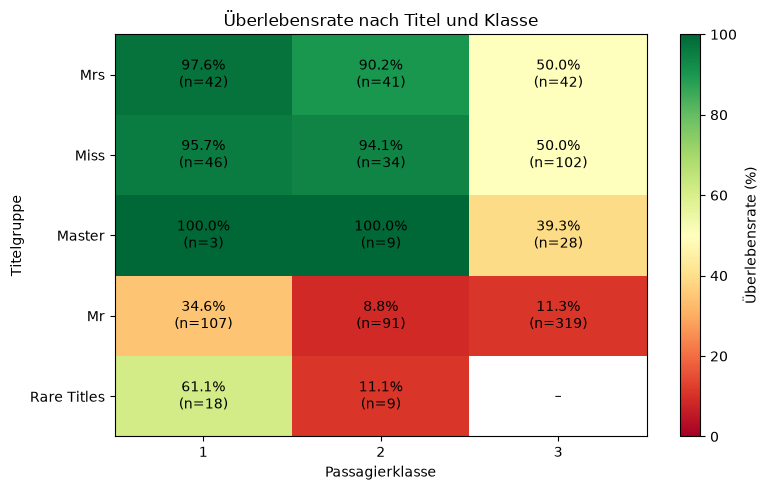

In [990]:
title_order = ["Mrs", "Miss", "Master", "Mr", "Rare Titles"]

rates = title_class_survival["survival_rate"].unstack("Pclass").reindex(title_order)
counts = title_class_survival["passengers"].unstack("Pclass").reindex(title_order)

fig, ax = plt.subplots(figsize=(8, 5))
heatmap = ax.imshow(rates, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")

ax.set_xticks(range(len(rates.columns)), labels=rates.columns)
ax.set_yticks(range(len(rates.index)), labels=rates.index)
ax.set_xlabel("Passagierklasse")
ax.set_ylabel("Titelgruppe")
ax.set_title("Überlebensrate nach Titel und Klasse")

for row in range(len(rates.index)):
    for col in range(len(rates.columns)):
        rate = rates.iloc[row, col]
        count = counts.iloc[row, col]
        label = f"{rate:.1f}%\n(n={int(count)})" if pd.notna(rate) else "–"
        ax.text(col, row, label, ha="center", va="center")

fig.colorbar(heatmap, ax=ax, label="Überlebensrate (%)")
plt.tight_layout()
plt.show()

## Geschlecht und Ticketpreis

In [991]:
sex_faregroup_survival = train_data.groupby(["Sex", "FareGroup"]).agg(
    passengers=("Survived", "count"),
    survival_rate=("Survived", "mean")
)

sex_faregroup_survival["survival_rate"] = (
    sex_faregroup_survival["survival_rate"].mul(100).round(1)
)

sex_faregroup_survival

passengers  survival_rate
Sex    FareGroup                           
female 0-40              221           66.5
       40-80              45           88.9
       >80                48           95.8
male   0-40              494           16.6
       40-80              57           28.1
       >80                26           42.3

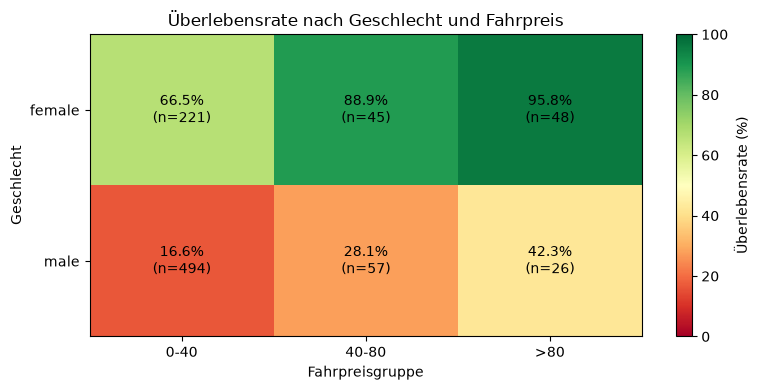

In [992]:
rates = sex_faregroup_survival["survival_rate"].unstack("FareGroup")
counts = sex_faregroup_survival["passengers"].unstack("FareGroup")

fig, ax = plt.subplots(figsize=(8, 4))
heatmap = ax.imshow(rates, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")

ax.set_xticks(range(len(rates.columns)), labels=rates.columns)
ax.set_yticks(range(len(rates.index)), labels=rates.index)
ax.set_xlabel("Fahrpreisgruppe")
ax.set_ylabel("Geschlecht")
ax.set_title("Überlebensrate nach Geschlecht und Fahrpreis")

for row in range(len(rates.index)):
    for col in range(len(rates.columns)):
        rate = rates.iloc[row, col]
        count = counts.iloc[row, col]
        label = f"{rate:.1f}%\n(n={int(count)})" if pd.notna(rate) else "–"
        ax.text(col, row, label, ha="center", va="center")

fig.colorbar(heatmap, ax=ax, label="Überlebensrate (%)")
plt.tight_layout()
plt.show()

## Klasse und Ticketpreis

In [993]:
class_faregroup_survival = train_data.groupby(["Pclass", "FareGroup"]).agg(
    passengers=("Survived", "count"),
    survival_rate=("Survived", "mean")
)

class_faregroup_survival["survival_rate"] = (
    class_faregroup_survival["survival_rate"].mul(100).round(1)
)

class_faregroup_survival

passengers  survival_rate
Pclass FareGroup                           
1      0-40               70           45.7
       40-80              72           65.3
       >80                74           77.0
2      0-40              174           47.7
       40-80              10           40.0
3      0-40              471           24.2
       40-80              20           25.0

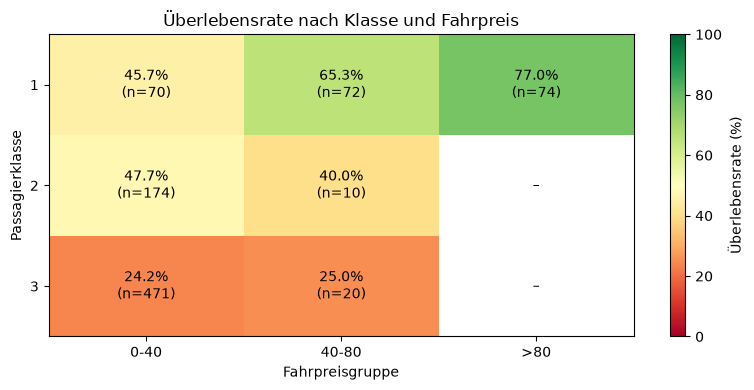

In [994]:
rates = class_faregroup_survival["survival_rate"].unstack("FareGroup")
counts = class_faregroup_survival["passengers"].unstack("FareGroup")

fig, ax = plt.subplots(figsize=(8, 4))
heatmap = ax.imshow(rates, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")

ax.set_xticks(range(len(rates.columns)), labels=rates.columns)
ax.set_yticks(range(len(rates.index)), labels=rates.index)
ax.set_xlabel("Fahrpreisgruppe")
ax.set_ylabel("Passagierklasse")
ax.set_title("Überlebensrate nach Klasse und Fahrpreis")

for row in range(len(rates.index)):
    for col in range(len(rates.columns)):
        rate = rates.iloc[row, col]
        count = counts.iloc[row, col]
        label = f"{rate:.1f}%\n(n={int(count)})" if pd.notna(rate) else "–"
        ax.text(col, row, label, ha="center", va="center")

fig.colorbar(heatmap, ax=ax, label="Überlebensrate (%)")
plt.tight_layout()
plt.show()

## Klasse und Familiengröße

In [995]:
class_family_survival = train_data.groupby(["Pclass", "FamilySizeGroup"]).agg(
    passengers=("Survived", "count"),
    survival_rate=("Survived", "mean")
)

class_family_survival["survival_rate"] = (
    class_family_survival["survival_rate"].mul(100).round(1)
)

class_family_survival

passengers  survival_rate
Pclass FamilySizeGroup                           
1      1                       109           53.2
       2                        70           72.9
       3                        24           75.0
       4                         7           71.4
       5                         2          100.0
       >5                        4           50.0
2      1                       104           34.6
       2                        34           52.9
       3                        31           67.7
       4                        13           76.9
       5                         1          100.0
       >5                        1          100.0
3      1                       324           21.3
       2                        57           35.1
       3                        47           42.6
       4                         9           66.7
       5                        12            0.0
       >5                       42            9.5

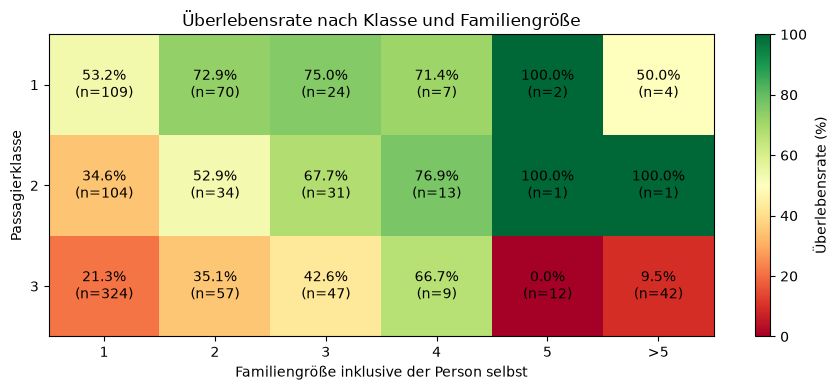

In [996]:
rates = class_family_survival["survival_rate"].unstack("FamilySizeGroup")
counts = class_family_survival["passengers"].unstack("FamilySizeGroup")

fig, ax = plt.subplots(figsize=(9, 4))
heatmap = ax.imshow(rates, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")

ax.set_xticks(range(len(rates.columns)), labels=rates.columns)
ax.set_yticks(range(len(rates.index)), labels=rates.index)
ax.set_xlabel("Familiengröße inklusive der Person selbst")
ax.set_ylabel("Passagierklasse")
ax.set_title("Überlebensrate nach Klasse und Familiengröße")

for row in range(len(rates.index)):
    for col in range(len(rates.columns)):
        rate = rates.iloc[row, col]
        count = counts.iloc[row, col]
        label = f"{rate:.1f}%\n(n={int(count)})" if pd.notna(rate) else "–"
        ax.text(col, row, label, ha="center", va="center")

fig.colorbar(heatmap, ax=ax, label="Überlebensrate (%)")
plt.tight_layout()
plt.show()